In [ ]:
#Import Python libraries.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import requests
from PIL import Image
from io import BytesIO

# **<font color='orange'>DATA OVERVIEW & PREPARATION</font>**

In [ ]:
#Data import.
from numpy import dtype
df = pd.read_csv('dataset_labels.csv')

In [ ]:
#Data overview.
display(df.head())
df.info()
df.describe(include='all').T

,image_id,location,location_id,image_date_time,media_url,species_common_name,age_class,sex_class,filepath
0,31553939,FEIUCS-23,49099,2020-03-31 15:24:21,https://wildtrax-cam-west.s3-accelerate.amazon...,Bison,Adult,Female,/content/drive/MyDrive/Data607_Project/all_ima...
1,31584779,FEIUCS-36,48413,2020-04-28 04:00:56,https://wildtrax-cam-west.s3-accelerate.amazon...,Bison,Adult,Unkn,/content/drive/MyDrive/Data607_Project/all_ima...
2,31513122,FEIUCS-4,48410,2020-05-15 08:00:10,https://wildtrax-cam-west.s3-accelerate.amazon...,Bison,Adult,Male,/content/drive/MyDrive/Data607_Project/all_ima...
3,32755756,FEIUCS-30,48417,2020-07-11 21:43:57,https://wildtrax-cam-west.s3-accelerate.amazon...,Bison,Juv,Unkn,/content/drive/MyDrive/Data607_Project/all_ima...
4,32767060,FEIUCS-30,48417,2019-10-31 10:30:51,https://wildtrax-cam-west.s3-accelerate.amazon...,Bison,Adult,Unkn,/content/drive/MyDrive/Data607_Project/all_ima...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   image_id             1800 non-null   int64 
 1   location             1800 non-null   object
 2   location_id          1800 non-null   int64 
 3   image_date_time      1800 non-null   object
 4   media_url            1800 non-null   object
 5   species_common_name  1800 non-null   object
 6   age_class            1800 non-null   object
 7   sex_class            1800 non-null   object
 8   filepath             1800 non-null   object
dtypes: int64(2), object(7)
memory usage: 126.7+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
image_id,1800.0,NaN,NaN,NaN,31726788.651667,392162.045481,31491741.0,31550816.5,31586378.0,31632569.25,32781912.0
location,1800,53,FEIUCS-30,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_id,1800.0,NaN,NaN,NaN,50564.671111,5464.373964,47628.0,48411.0,48419.0,48437.0,64893.0
image_date_time,1800,1800,2020-03-10 12:38:31,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
media_url,1800,1800,https://wildtrax-cam-west.s3-accelerate.amazon...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
species_common_name,1800,6,Bison,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_class,1800,2,Adult,1749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex_class,1800,3,Unkn,1299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
filepath,1800,1800,/content/drive/MyDrive/Data607_Project/all_ima...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Data cleaning.
df['image_date_time'] = pd.to_datetime(df['image_date_time'])
df['sex_class'] = df['sex_class'].replace('Unkn', 'Unknown')
df['age_class'] = df['age_class'].replace('Unkn', 'Unknown')

In [ ]:
#Post-cleaning overview.
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   image_id             1800 non-null   int64         
 1   location             1800 non-null   object        
 2   location_id          1800 non-null   int64         
 3   image_date_time      1800 non-null   datetime64[ns]
 4   media_url            1800 non-null   object        
 5   species_common_name  1800 non-null   object        
 6   age_class            1800 non-null   object        
 7   sex_class            1800 non-null   object        
 8   filepath             1800 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 126.7+ KB


,image_id,location,location_id,image_date_time,media_url,species_common_name,age_class,sex_class,filepath
count,1.800000e+03,1800,1800.000000,1800,1800,1800,1800,1800,1800
unique,NaN,53,NaN,NaN,1800,6,2,3,1800
top,NaN,FEIUCS-30,NaN,NaN,https://wildtrax-cam-west.s3-accelerate.amazon...,Bison,Adult,Unknown,/content/drive/MyDrive/Data607_Project/all_ima...
freq,NaN,200,NaN,NaN,1,300,1749,1299,1
mean,3.172679e+07,NaN,50564.671111,2020-02-26 01:34:40.757222144,NaN,NaN,NaN,NaN,NaN
min,3.149174e+07,NaN,47628.000000,2019-10-10 07:22:25,NaN,NaN,NaN,NaN,NaN
25%,3.155082e+07,NaN,48411.000000,2019-12-17 22:21:08,NaN,NaN,NaN,NaN,NaN
50%,3.158638e+07,NaN,48419.000000,2020-02-24 06:03:50.500000,NaN,NaN,NaN,NaN,NaN
75%,3.163257e+07,NaN,48437.000000,2020-05-09 22:06:04,NaN,NaN,NaN,NaN,NaN
max,3.278191e+07,NaN,64893.000000,2020-10-13 09:34:17,NaN,NaN,NaN,NaN,NaN


# **<font color='orange'>1. Species Distribution Bar Chart </font>**

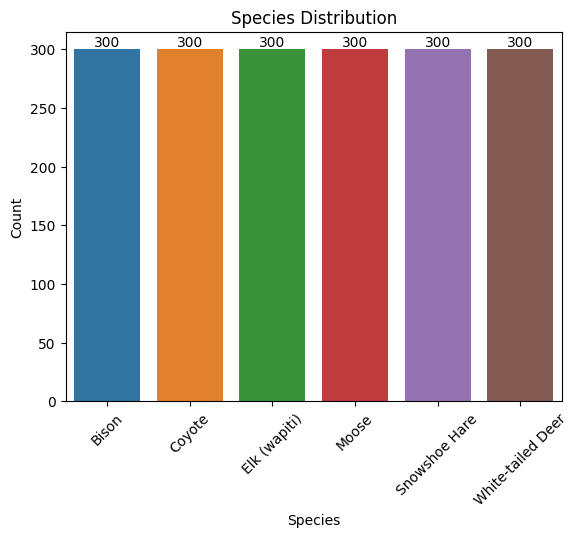

In [ ]:
#Bar graph - species distribution.
ax = sns.countplot(data=df, x='species_common_name', hue='species_common_name', legend=False)
plt.title('Species Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=45)

#Add exact counts on top of each bar.
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

# <font color='orange'>**2. Feature Distributions**</font>

## **2.1 Age Class Distribution**

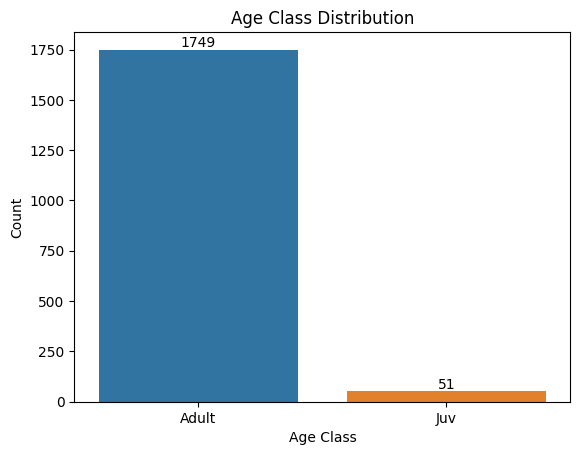

In [ ]:
#Bar graph - age class distribution.
ax = sns.countplot(data=df, x='age_class', hue='age_class', legend=False)
plt.title('Age Class Distribution')
plt.xlabel('Age Class')
plt.ylabel('Count')

#Add exact counts on top of each bar.
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

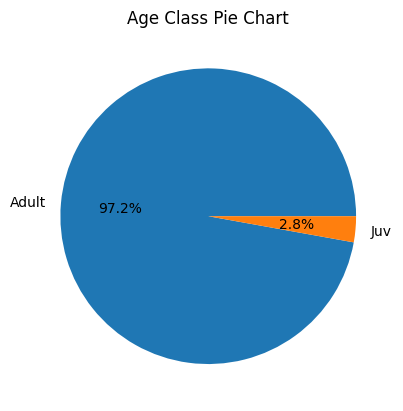

In [ ]:
df['age_class'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%')
plt.title('Age Class Pie Chart')
plt.ylabel('')
plt.show()

## **2.2 Sex Class Distribution**

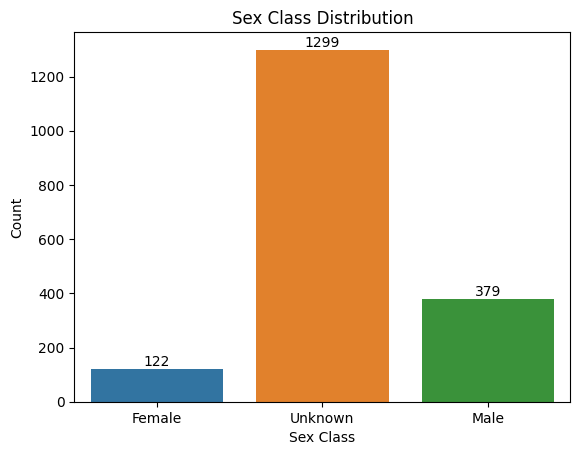

In [ ]:
#Bar graph - sex class distribution.
ax = sns.countplot(data=df, x='sex_class', hue='sex_class', legend=False)
plt.title('Sex Class Distribution')
plt.xlabel('Sex Class')
plt.ylabel('Count')

#Add exact counts on top of each bar.
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

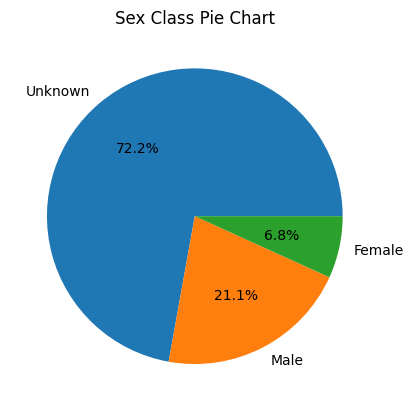

In [ ]:
df['sex_class'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%')
plt.title('Sex Class Pie Chart')
plt.ylabel('')
plt.show()

# **<font color='orange'>3. Sample Image Visualization</font>**

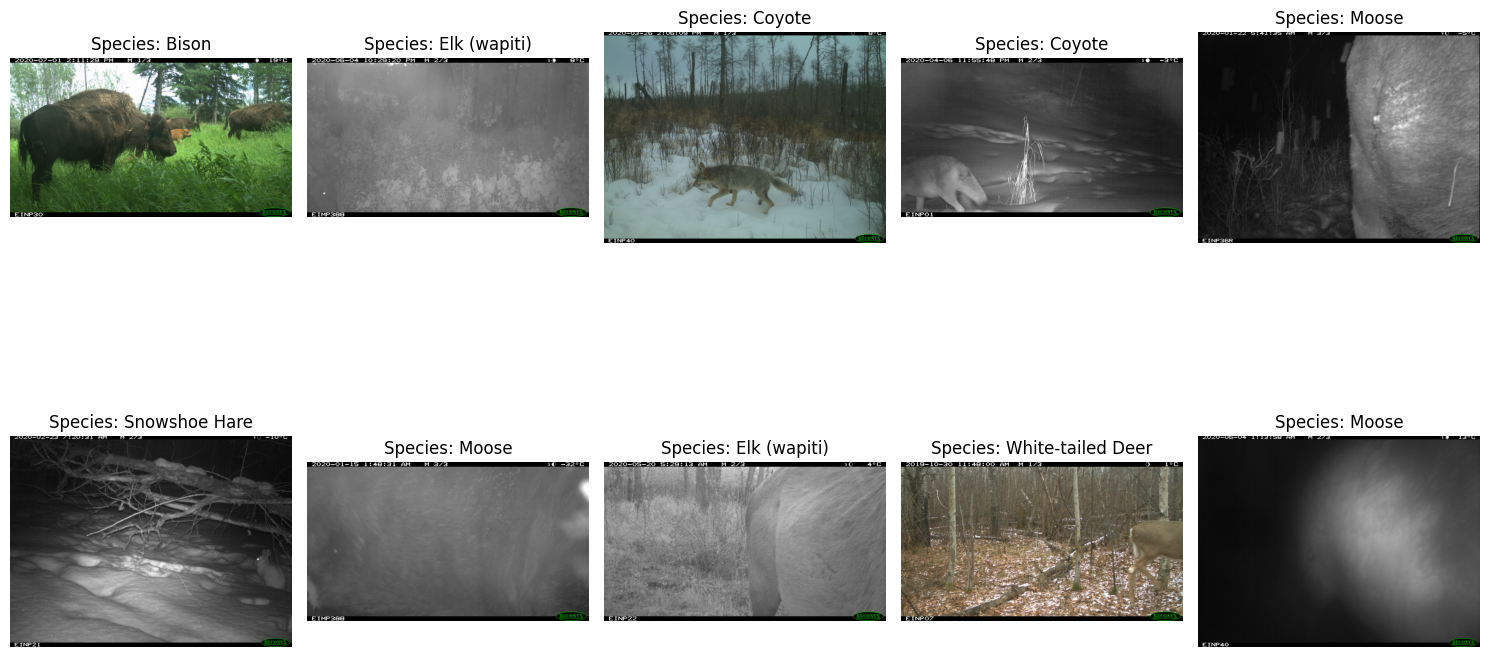

In [ ]:
#Sample 10 random images.
sample_df = df.sample(n=10)

plt.figure(figsize=(15, 10))

for i, (_, row) in enumerate(sample_df.iterrows()):
  response = requests.get(row['media_url'])
  img = Image.open(BytesIO(response.content))

  plt.subplot(2, 5, i + 1)
  plt.imshow(img)
  plt.title(f"Species: {row['species_common_name']}")
  plt.axis('off')

plt.tight_layout()
plt.show()

# **<font color='orange'>4. Spatial Distribution</font>**

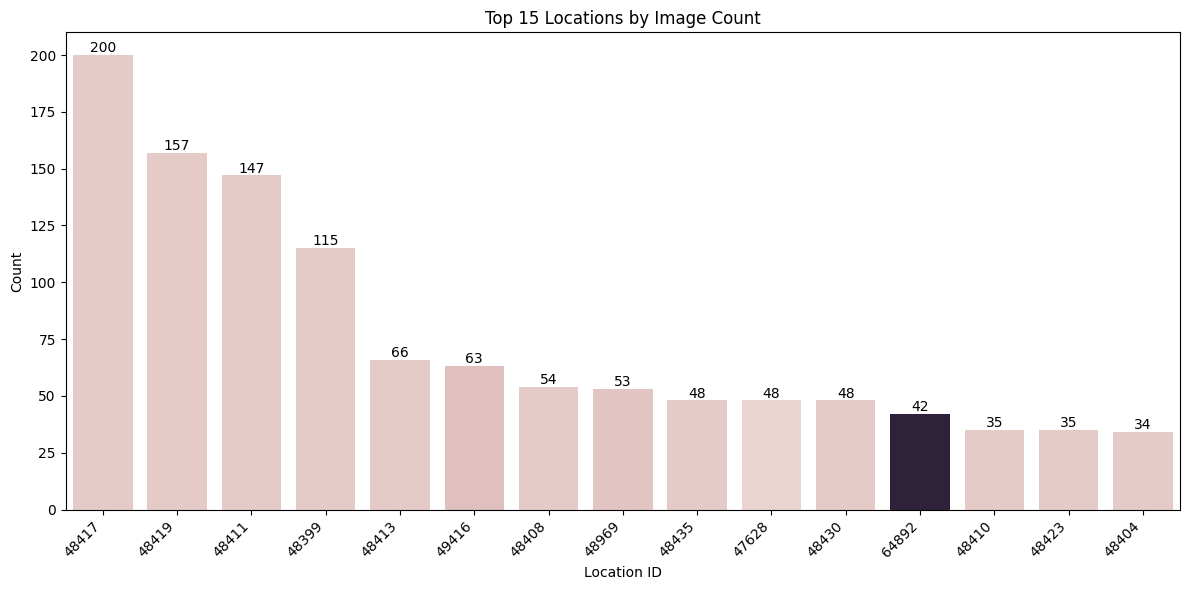

In [ ]:
#Bar graph - top 15 location distribution.
#Get the top 15 location IDs.
top_15_locations = df['location_id'].value_counts().head(15).index

#Filter the DataFrame to include only these top 15 locations.
df_top_locations = df[df['location_id'].isin(top_15_locations)]

plt.figure(figsize=(12, 6)) #Adjust figure size for better readability of many bars.
ax = sns.countplot(data=df_top_locations, x='location_id', hue='location_id', legend=False, order=top_15_locations)
plt.title('Top 15 Locations by Image Count')
plt.xlabel('Location ID')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

#Add exact counts on top of each bar.
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# **<font color='orange'>5. Temporal Distribution</font>**

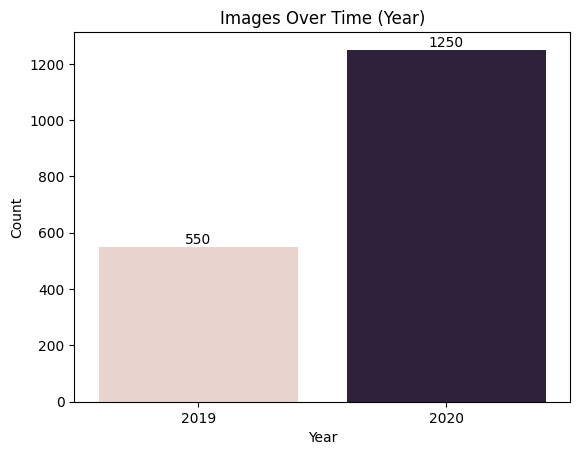

In [ ]:
#Bar graph - temporal distribution.
df['year'] = df['image_date_time'].dt.year
ax = sns.countplot(data=df, x='year', hue='year', legend=False)
plt.title('Images Over Time (Year)')
plt.xlabel('Year')
plt.ylabel('Count')

#Add exact counts on top of each bar.
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

## **5.1 Seasonality/Monthly Trends**

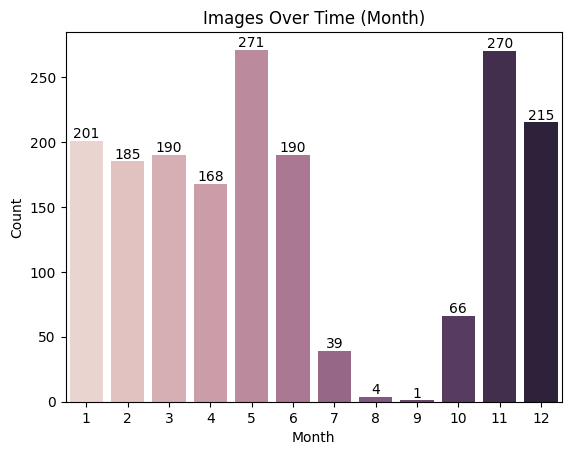

In [ ]:
#Bar graph - temporal distribution.
df['month'] = df['image_date_time'].dt.month
ax = sns.countplot(data=df, x='month', hue='month', legend=False)
plt.title('Images Over Time (Month)')
plt.xlabel('Month')
plt.ylabel('Count')

#Add exact counts on top of each bar.
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

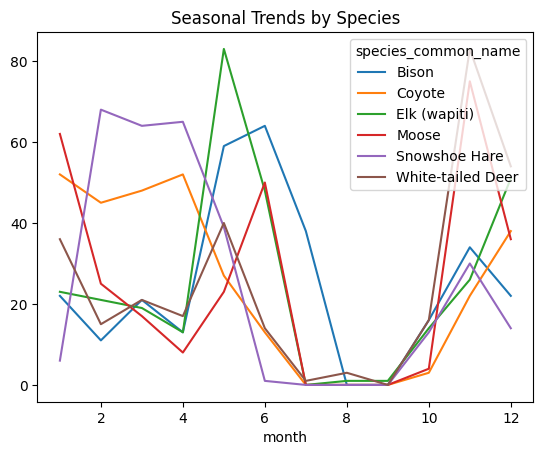

In [ ]:
#Per species.
pd.crosstab(df['month'], df['species_common_name']).plot()
plt.title('Seasonal Trends by Species')
plt.show()

# **<font color='orange'>6. Feature Relationships</font>**

## **6.1 Species vs Age Class**

In [ ]:
pd.crosstab(df['species_common_name'], df['age_class']).head()

age_class,Adult,Juv
species_common_name,,
Bison,267,33
Coyote,300,0
Elk (wapiti),293,7
Moose,289,11
Snowshoe Hare,300,0


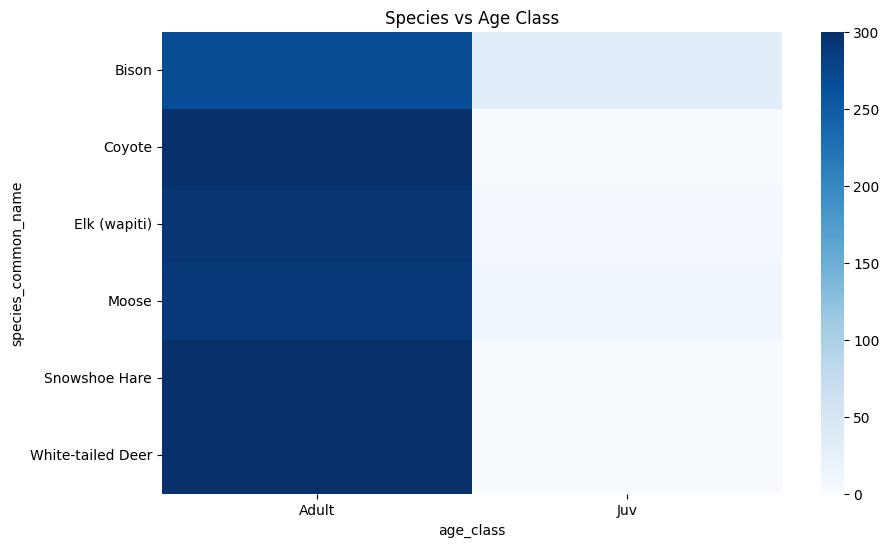

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(pd.crosstab(df['species_common_name'], df['age_class']), cmap='Blues')
plt.title('Species vs Age Class')
plt.show()

## **6.2 Species vs Sex Class**

In [ ]:
pd.crosstab(df['species_common_name'], df['sex_class']).head()

sex_class,Female,Male,Unknown
species_common_name,,,
Bison,17,20,263
Coyote,0,0,300
Elk (wapiti),46,104,150
Moose,25,156,119
Snowshoe Hare,0,0,300


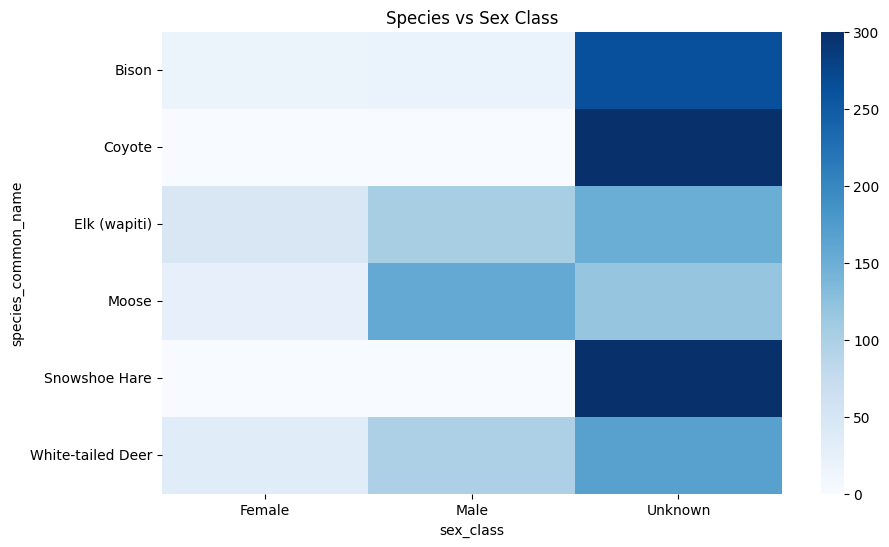

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(pd.crosstab(df['species_common_name'], df['sex_class']), cmap='Blues')
plt.title('Species vs Sex Class')
plt.show()

# **<font color='orange'>7. Day vs Night Activity</font>**

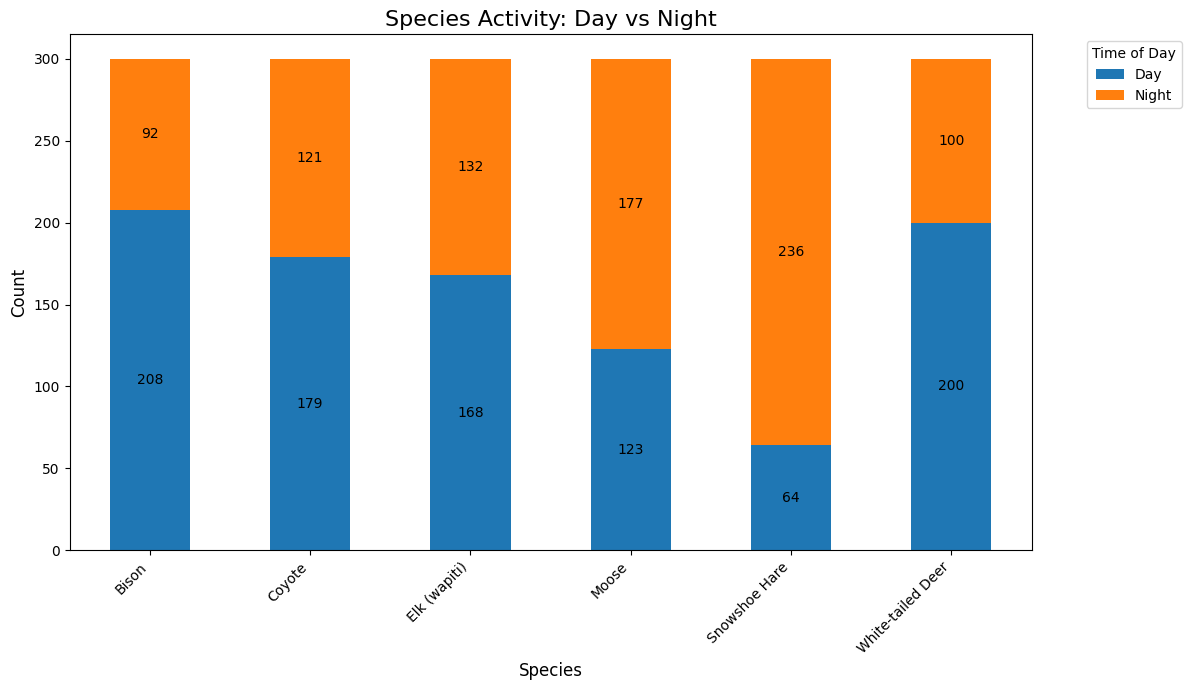

In [ ]:
df['hour'] = df['image_date_time'].dt.hour

df['time_of_day'] = df['hour'].apply(
    lambda x: 'Day' if 6 <= x < 18 else 'Night'
)

#Create a crosstab for the stacked bar chart.
crosstab_df = pd.crosstab(df['species_common_name'], df['time_of_day'])

#Plotting using seaborn for better aesthetics.
ax = crosstab_df.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Species Activity: Day vs Night', fontsize=16)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Species', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time of Day', bbox_to_anchor=(1.05, 1), loc='upper left')

#Add exact counts on top of each bar segment.
for c in ax.containers:
    labels = [f'{v.get_height():.0f}' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

plt.tight_layout()
plt.show()

# **<font color='orange'>8. Activity Heatmap</font>**

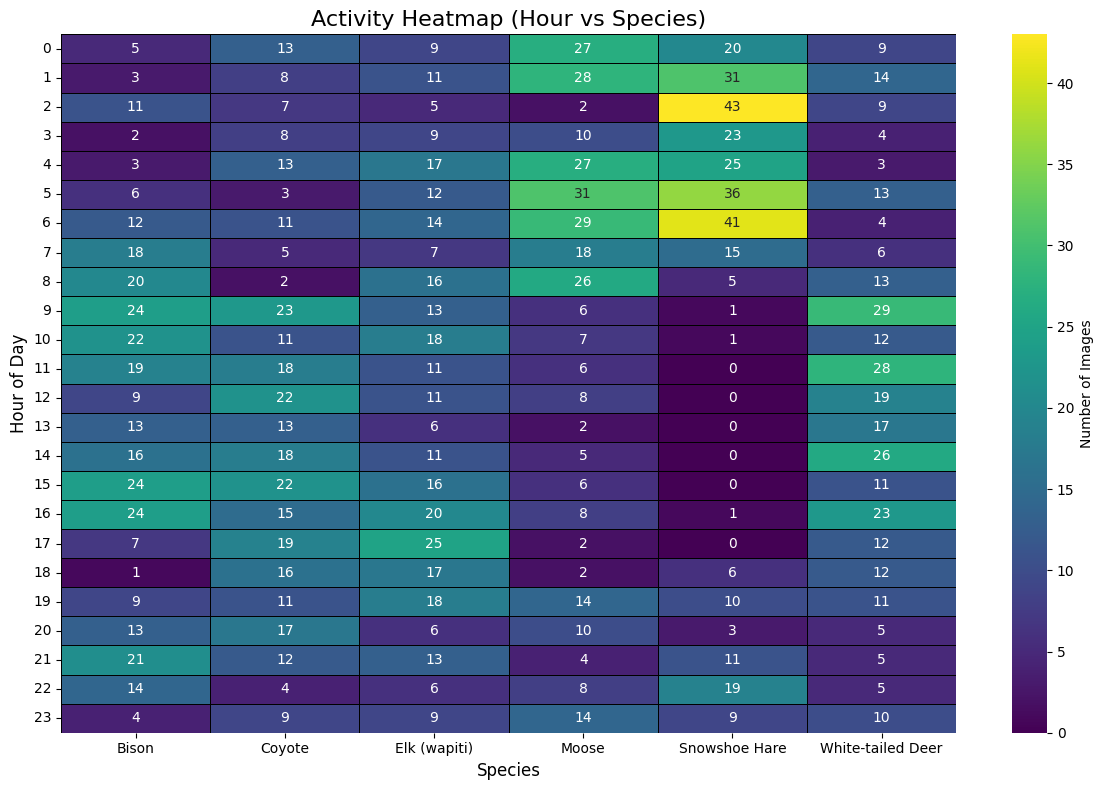

In [ ]:
activity = pd.crosstab(df['hour'], df['species_common_name'])

plt.figure(figsize=(12,8))
sns.heatmap(activity, cmap='viridis', annot=True, fmt='d', linewidths=.5, linecolor='black', cbar_kws={'label': 'Number of Images'})
plt.title('Activity Heatmap (Hour vs Species)', fontsize=16)
plt.xlabel('Species', fontsize=12)
plt.ylabel('Hour of Day', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **<font color='orange'>9. Species Co-occurrence</font>**

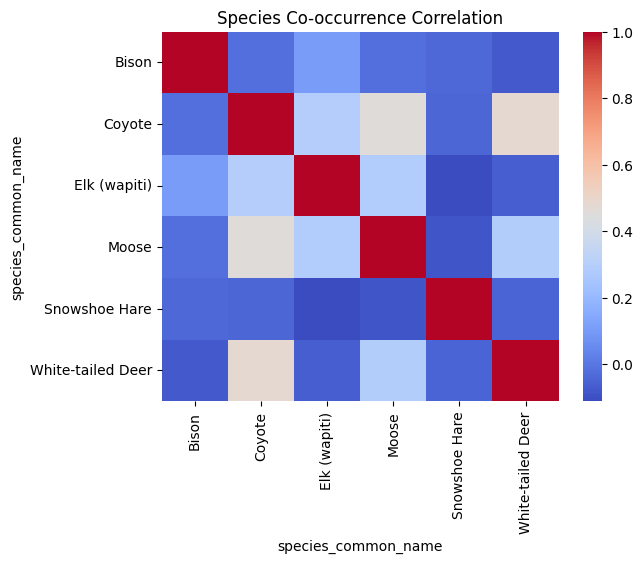

In [ ]:
species_location = pd.crosstab(df['location_id'], df['species_common_name'])

sns.heatmap(species_location.corr(), cmap='coolwarm')
plt.title('Species Co-occurrence Correlation')
plt.show()